In [ ]:
#Preflight v2: fail on real breakage, warn otherwise 
import sys, importlib, platform

STRICT = False  

CORE = ["pandas", "numpy", "sklearn", "tensorflow"]
OPTIONAL = ["torch", "ultralytics", "transformers", "sentence_transformers"]

def get_ver(mod, attr="__version__"):
    try:
        m = importlib.import_module(mod)
        return getattr(m, attr, "0.0.0")
    except Exception:
        return None


def vtuple(v):
    from packaging.version import Version
    return Version(v or "0")

problems, warnings = [], []
installed = {m: get_ver(m) for m in CORE + OPTIONAL}

#Core presence check 
for m in CORE:
    if installed[m] is None:
        problems.append(f"Missing required package: {m} (pip install {m.replace('_','-')})")

# Known-breaking combo guard
st = installed["sentence_transformers"]
tr = installed["transformers"]
if st is not None and tr is not None:
    if vtuple(st) < vtuple("3.0.0") and vtuple(tr) >= vtuple("4.48.0"):
        problems.append(
            "Incompatible pair: sentence-transformers<3.0 with transformers>=4.48.\n"
            "Fix: pip install 'sentence-transformers>=3.0.0' OR pin 'transformers<4.48'."
        )

# TensorFlow vs NumPy heads-up 
tf = installed["tensorflow"]
npv = installed["numpy"]
if tf is not None and npv is not None and vtuple(npv) >= vtuple("2.0.0"):
    warnings.append(
        f"NumPy {npv} with TensorFlow {tf}: if you see odd errors, consider NumPy < 2.0 "
        "(but if TF already imports fine, you can ignore this)."
    )

print("Python:", sys.version.split()[0], "| Platform:", platform.platform())
print("Detected versions:", {k: v for k, v in installed.items() if v})

if problems:
    print("\nBlocking issues:")
    for p in problems:
        print(" -", p)
    raise SystemExit(1)

if warnings:
    print("\nWarnings (non-blocking):")
    for w in warnings:
        print(" -", w)

if STRICT:
    # Example strict checks you can keep/extend:
    target_min = {
        "pandas": "2.2.0",
        "numpy": "1.26.0",
        "scikit_learn": "1.4.0",
        "tensorflow": "2.16.0",
    }
    strict_issues = []
    for m, minv in target_min.items():
        if installed[m] is not None and vtuple(installed[m]) < vtuple(minv):
            strict_issues.append(f"{m}>={minv} required, found {installed[m]}")
    if strict_issues:
        print("\nSTRICT mode failed:")
        for s in strict_issues:
            print(" -", s)
        raise SystemExit(1)

print("\nPreflight OK — proceeding.")


Python: 3.12.3 | Platform: macOS-13.7.7-x86_64-i386-64bit
Detected versions: {'pandas': '2.2.2', 'numpy': '1.26.4', 'sklearn': '1.4.2', 'tensorflow': '2.16.2', 'torch': '2.2.2', 'ultralytics': '8.2.0', 'transformers': '4.39.3', 'sentence_transformers': '2.7.0'}

Preflight OK — proceeding.


In [ ]:
# Caching & checkpoint utilities 
from pathlib import Path
import json, time, pickle, os

# Limit CPU threads on macOS to avoid slowdown
os.environ.setdefault("OMP_NUM_THREADS","4")
os.environ.setdefault("OPENBLAS_NUM_THREADS","4")
os.environ.setdefault("MKL_NUM_THREADS","4")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS","4")
os.environ.setdefault("NUMEXPR_NUM_THREADS","4")

ARTIFACTS = Path("./artifacts")
ARTIFACTS.mkdir(exist_ok=True)

def already(path):
    p = Path(path)
    return p.exists() and p.stat().st_size > 0

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def timed(msg):
    def _decor(fn):
        def wrapper(*a, **k):
            t0 = time.time()
            print(f"[START] {msg} …")
            out = fn(*a, **k)
            print(f"[DONE]  {msg} in {time.time()-t0:.1f}s")
            return out
        return wrapper
    return _decor

# Quick test mode
SMOKE_TEST = True
print(f"SMOKE_TEST = {SMOKE_TEST}")


SMOKE_TEST = True


In [ ]:
#TF-IDF caching
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

TFIDF_PATH = ARTIFACTS / "tfidf.pkl"
TFIDF_MATRIX = ARTIFACTS / "tfidf_matrix.pkl"
DATA_CSV = "amazon_reviews_us_Apparel_v1_00.csv"

def _get_reviews_sample(n=20000 if not SMOKE_TEST else 2000):
    df = pd.read_csv(DATA_CSV, nrows=n)
    df = df.dropna(subset=["review_body"])
    return df["review_body"].astype(str).tolist()

if already(TFIDF_PATH) and already(TFIDF_MATRIX):
    print("Reusing cached TF-IDF.")
    tfidf = load_pickle(TFIDF_PATH)
    X_tfidf = load_pickle(TFIDF_MATRIX)
else:
    texts = _get_reviews_sample()
    tfidf = TfidfVectorizer(max_features=50000 if not SMOKE_TEST else 5000)
    X_tfidf = tfidf.fit_transform(texts)
    save_pickle(tfidf, TFIDF_PATH)
    save_pickle(X_tfidf, TFIDF_MATRIX)
    print("Saved TF-IDF artifacts.")


Saved TF-IDF artifacts.


/var/folders/9d/7216hsv562lbddcy7qb278zc0000gp/T/ipykernel_8077/4250465806.py:24: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(str(text), "html.parser").get_text()



Summary Stats for Ratings and Helpful Votes:

        star_rating  helpful_votes   total_votes
count  49971.000000   49971.000000  49971.000000
mean       3.968822       1.650717      1.952693
std        1.401930       9.555778     10.072284
min        1.000000       0.000000      0.000000
25%        3.000000       0.000000      0.000000
50%        5.000000       0.000000      0.000000
75%        5.000000       1.000000      1.000000
max        5.000000     628.000000    634.000000

Correlation Matrix:
                           star_rating  helpful_votes  total_votes  \
star_rating                  1.000000       0.010724    -0.001115   
helpful_votes                0.010724       1.000000     0.992122   
total_votes                 -0.001115       0.992122     1.000000   
verified_purchase_binary    -0.115033      -0.019860    -0.027789   

                          verified_purchase_binary  
star_rating                              -0.115033  
helpful_votes                         

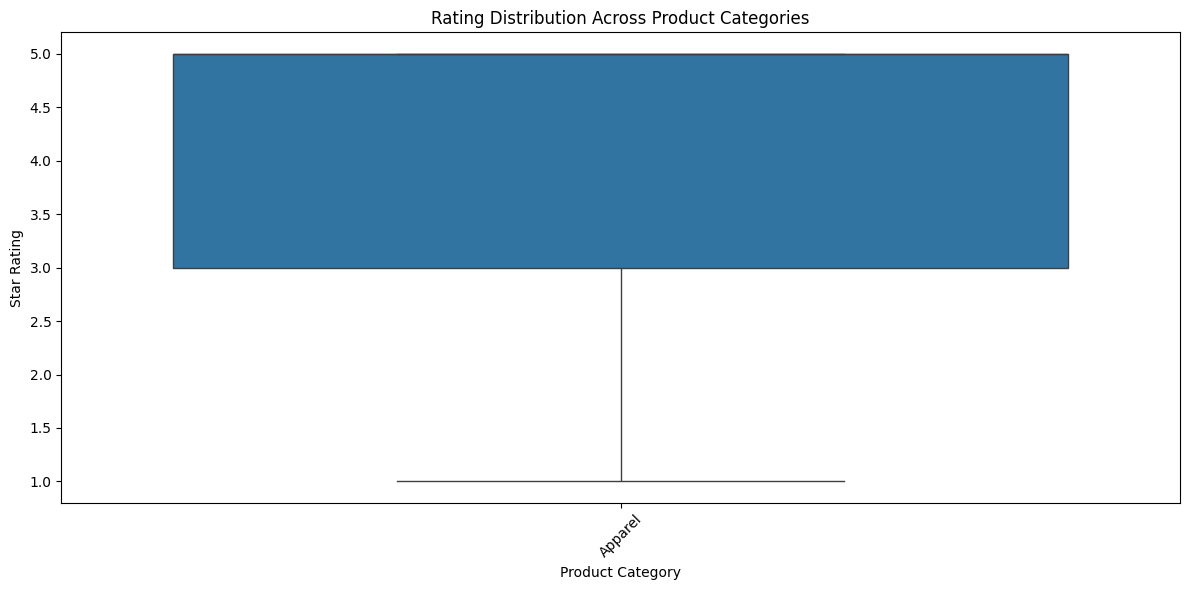


Central Tendency & Dispersion for star_rating:
Mean: 3.97, Median: 5.0, Mode: 5, Std Dev: 1.40

Hypothesis Test: Verified vs Non-Verified Star Ratings
T-Statistic: -28.114, P-Value: 0.0000
=> Statistically significant: Verified purchases have different ratings.

Bayesian Probability P(helpful | total_votes > 0): 0.8323


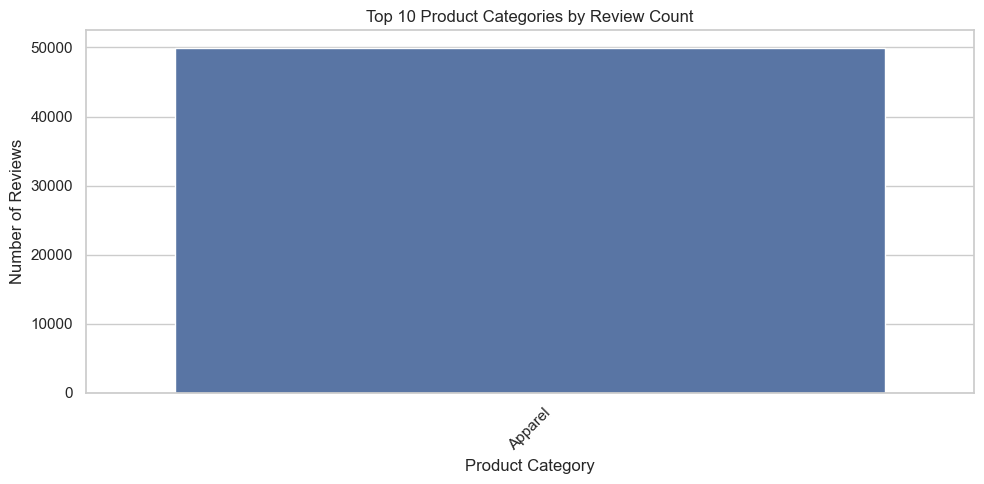

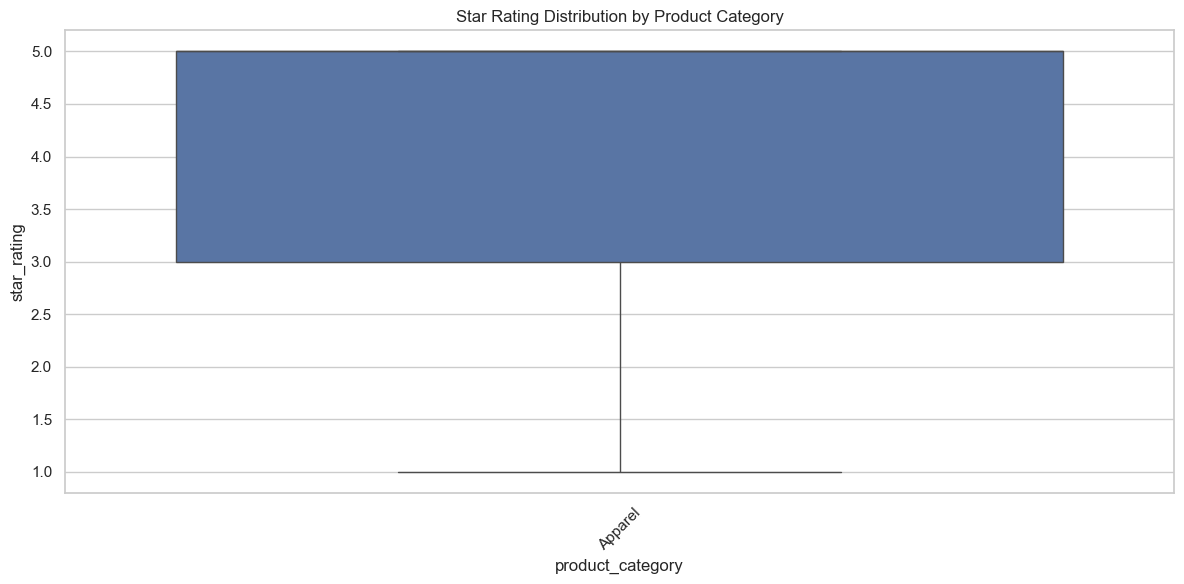

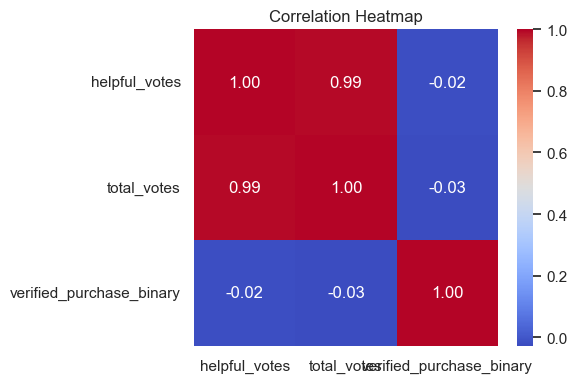

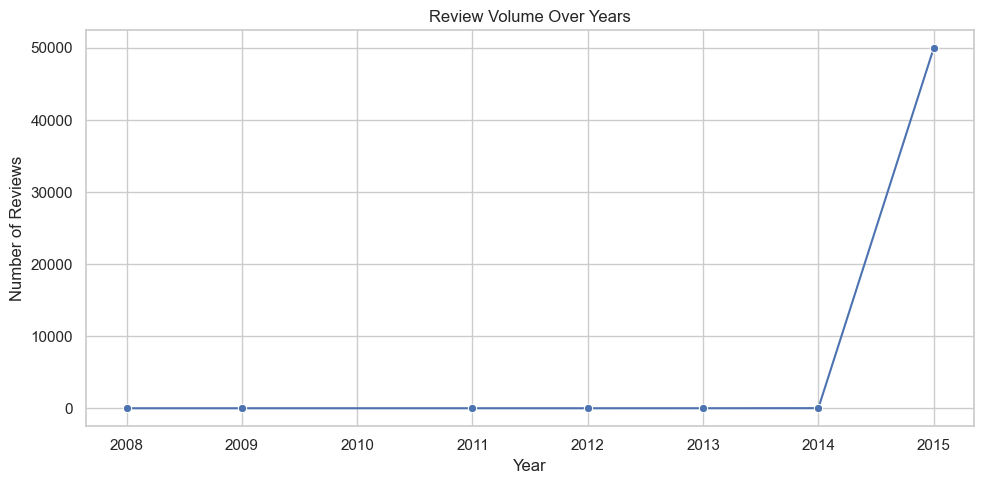


Feature Engineering Summary:
   review_length  verified_purchase_binary  vine_binary  total_votes_scaled  \
0            523                         1            0            0.000000   
1             69                         1            0            0.003155   
2             15                         1            0            0.000000   
3             31                         1            0            0.000000   
4              8                         1            0            0.000000   

   helpful_votes_scaled  review_length_scaled  
0              0.000000              0.417398  
1              0.001592              0.055068  
2              0.000000              0.011971  
3              0.000000              0.024741  
4              0.000000              0.006385  


In [ ]:
# Section 1: Data analysis and preprocessing

import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


# Load data
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)

# STEP 1: Preprocessing
df = df.dropna(subset=["review_body", "star_rating", "verified_purchase"])
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce', dayfirst=True)
df['review_year'] = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month
df['review_dayofweek'] = df['review_date'].dt.day_name()

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

df['cleaned_review_body'] = df['review_body'].apply(clean_text)

#EDA
print("\nSummary Stats for Ratings and Helpful Votes:\n")
print(df[['star_rating', 'helpful_votes', 'total_votes']].describe())

# Add binary flag for verified purchase
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})

# Correlation matrix
corr_matrix = df[['star_rating', 'helpful_votes', 'total_votes', 'verified_purchase_binary']].corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# Most and least reviewed products
review_counts = df['product_id'].value_counts()
most_reviewed = review_counts.head(5)
least_reviewed = review_counts.tail(5)

print("\nMost Reviewed Products:\n", most_reviewed)
print("\nLeast Reviewed Products:\n", least_reviewed)

# Rating distribution by product category
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='star_rating', data=df)
plt.xticks(rotation=45)
plt.title("Rating Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()


# Measures of central tendency and dispersion for star_rating
mean_rating = df['star_rating'].mean()
median_rating = df['star_rating'].median()
mode_rating = df['star_rating'].mode()[0]
std_rating = df['star_rating'].std()

print("\nCentral Tendency & Dispersion for star_rating:")
print(f"Mean: {mean_rating:.2f}, Median: {median_rating}, Mode: {mode_rating}, Std Dev: {std_rating:.2f}")

#Hypothesis Testing - Do verified purchases have higher ratings?
verified = df[df['verified_purchase'] == 'Y']['star_rating']
not_verified = df[df['verified_purchase'] == 'N']['star_rating']

t_stat, p_value = stats.ttest_ind(verified, not_verified, equal_var=False)
print("\nHypothesis Test: Verified vs Non-Verified Star Ratings")
print(f"T-Statistic: {t_stat:.3f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant: Verified purchases have different ratings.")
else:
    print(" Not statistically significant: No difference in ratings.")

# STEP 3.3: Bayesian Probability - Likelihood of a review being helpful
# P(helpful | total_votes > 0) = (# helpful_votes > 0 and total_votes > 0) / (# total_votes > 0)
df_votes = df[df['total_votes'] > 0]
helpful_given_voted = (df_votes['helpful_votes'] > 0).sum() / len(df_votes)

print(f"\nBayesian Probability P(helpful | total_votes > 0): {helpful_given_voted:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent style
sns.set(style="whitegrid")

#Bar chart - most popular product categories by review count
plt.figure(figsize=(10, 5))
top_categories = df['product_category'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top 10 Product Categories by Review Count")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Box plot - distribution of star ratings across categories
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='star_rating', data=df)
plt.title("Star Rating Distribution by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap - correlation of helpful_votes, total_votes, and verified_purchase_binary
corr_features = df[['helpful_votes', 'total_votes', 'verified_purchase_binary']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_features, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#Time series line chart - number of reviews over time (by year)
plt.figure(figsize=(10, 5))
reviews_by_year = df['review_year'].value_counts().sort_index()
sns.lineplot(x=reviews_by_year.index, y=reviews_by_year.values, marker='o')
plt.title("Review Volume Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


#Create review_length feature
df['review_length'] = df['cleaned_review_body'].apply(lambda x: len(str(x).split()))

#Convert 'verified_purchase' and 'vine' to numerical format
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})
df['vine_binary'] = df['vine'].map({'Y': 1, 'N': 0})

#One-hot encode 'product_category'
df = pd.get_dummies(df, columns=['product_category'], drop_first=True)

#Normalize numerical features (total_votes, helpful_votes, review_length)
scaler = MinMaxScaler()
df[['total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']] = scaler.fit_transform(
    df[['total_votes', 'helpful_votes', 'review_length']]
)

#Confirm engineered features
print("\nFeature Engineering Summary:")
print(df[['review_length', 'verified_purchase_binary', 'vine_binary',
          'total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']].head())






Linear:
R2: 0.35099725240778246
MSE: 1.2873568764513583
RMSE: 1.1346175022673317

Ridge:
R2: 0.35099433968221583
MSE: 1.2873626541114704
RMSE: 1.13462004834723

Lasso:
R2: 0.2884416621165855
MSE: 1.411441665954354
RMSE: 1.1880411044885417


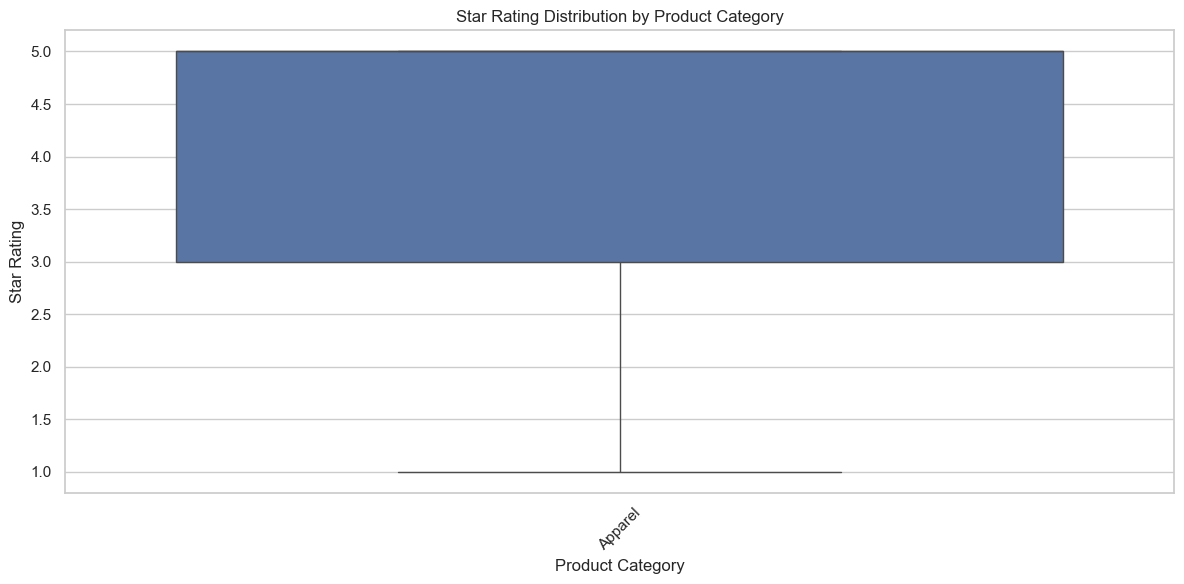

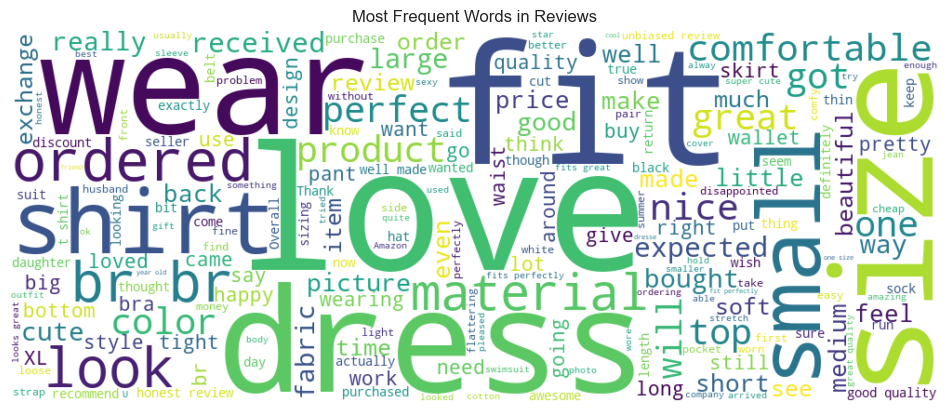

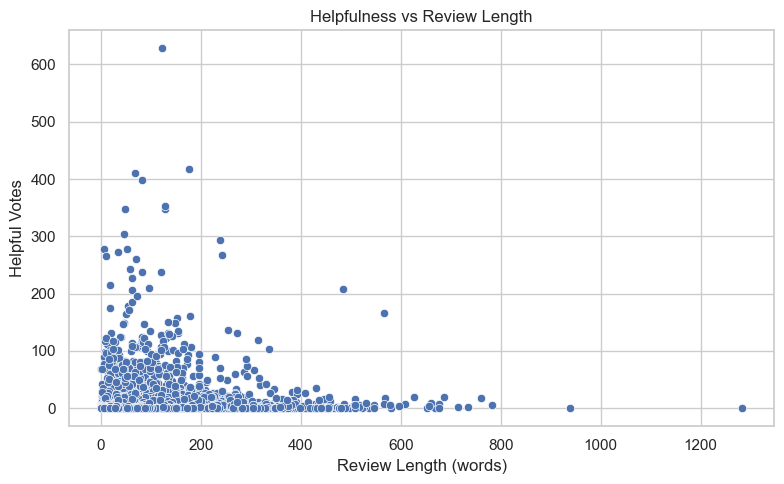

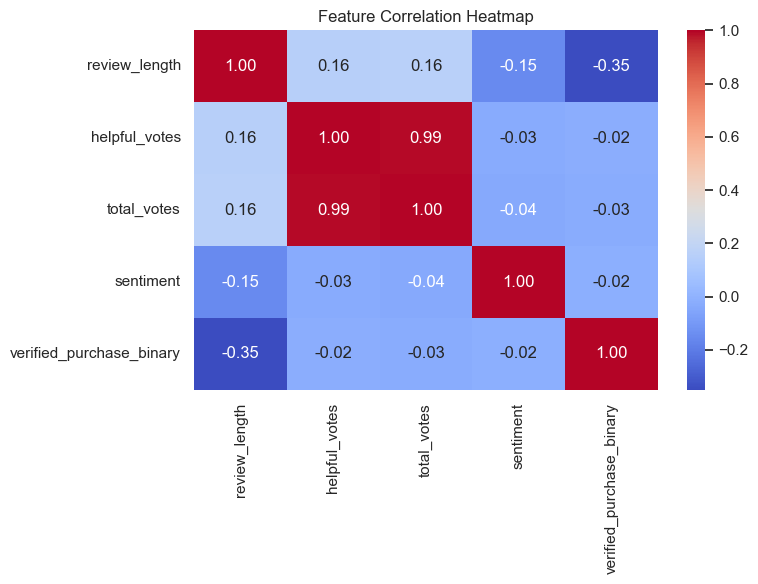

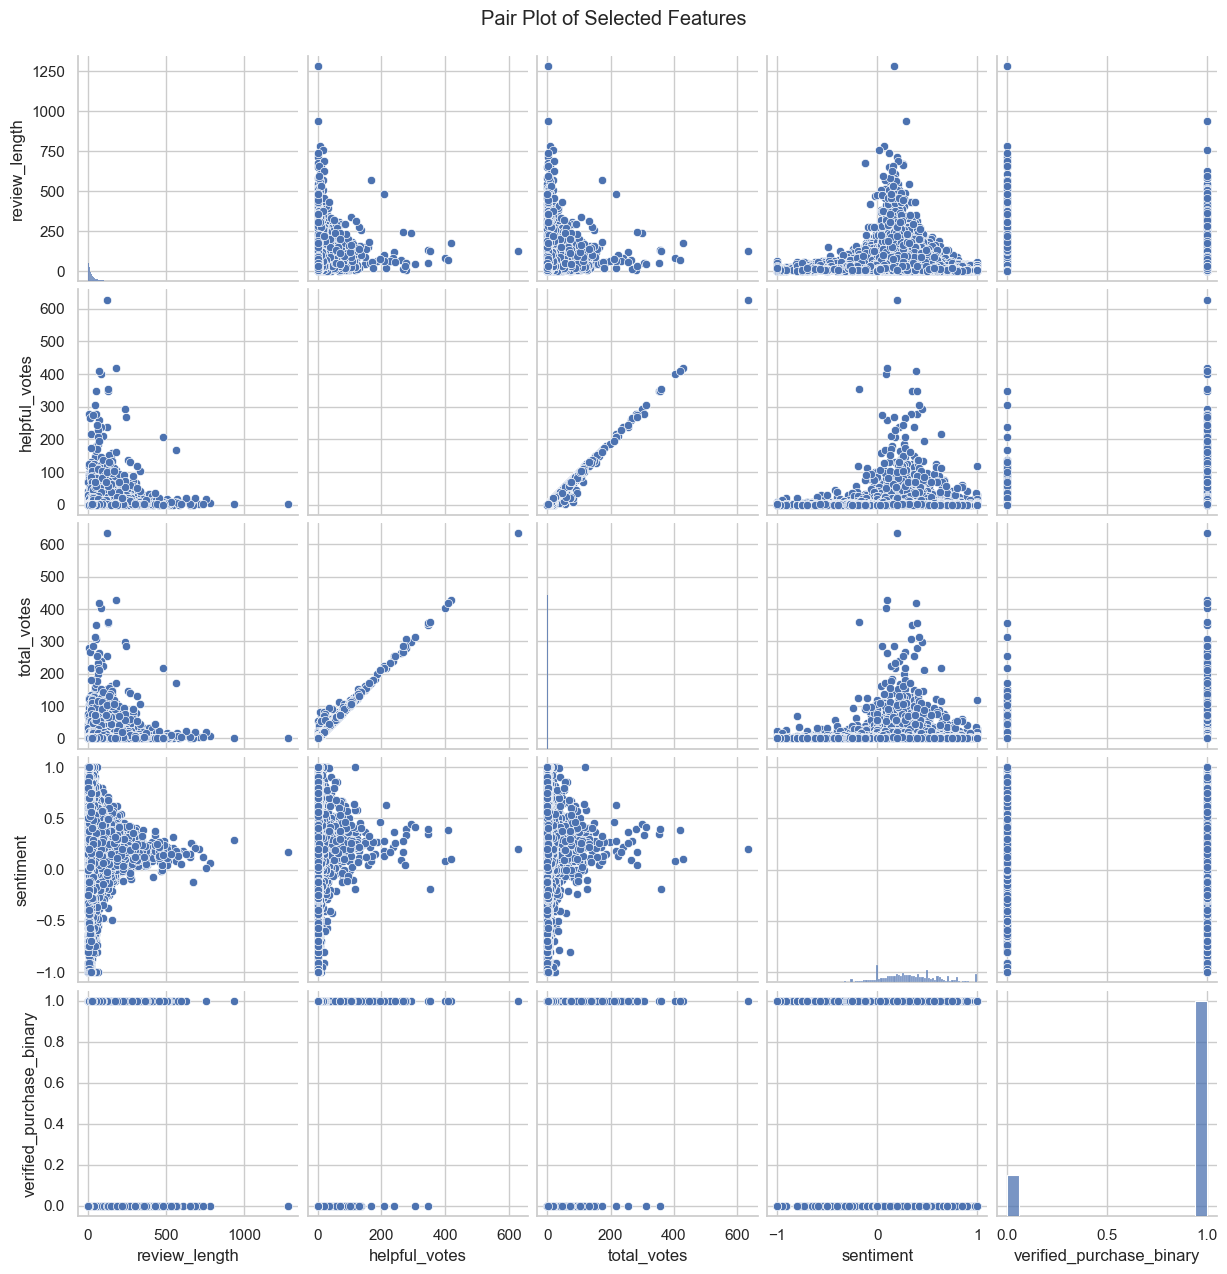

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


Logistic Regression:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Decision Tree:
              precision    recall  f1-score   support

    negative       0.04      0.00      0.00       756
     neutral       0.23      0.03      0.05      1719
    positive       0.75      0.98      0.85      7520

    accuracy                           0.74      9995
   macro avg       0.34      0.34      0.30      9995
weighted avg       0.61      0.74      0.65      9995


Random Forest:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.26      0.02      0.04      1719
    positive       0.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


KNN:
              precision    recall  f1-score   support

    negative       0.08      0.03      0.04       756
     neutral       0.20      0.11      0.14      1719
    positive       0.76      0.89      0.82      7520

    accuracy                           0.69      9995
   macro avg       0.35      0.34      0.33      9995
weighted avg       0.61      0.69      0.64      9995


SMOTE:
               precision    recall  f1-score   support

    negative       0.10      0.74      0.18       756
     neutral       0.21      0.33      0.26      1719
    positive       0.84      0.19      0.31      7520

    accuracy                           0.25      9995
   macro avg       0.38      0.42      0.25      9995
weighted avg       0.68      0.25      0.29      9995


Undersampling:
               precision    recall  f1-score   support

    negative       0.10      0.74      0.18       756
     neutral       0.21      0.34      0.26      1719
    positive       0.84      0.18      0.30

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/L


AdaBoost:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Gradient Boosting:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.33      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.36      0.33      0.29      9995
weighted avg       0.62      0.75      0.65      9995



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  


Stacked Model:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.00      0.00      0.00      1719
    positive       0.75      1.00      0.86      7520

    accuracy                           0.75      9995
   macro avg       0.25      0.33      0.29      9995
weighted avg       0.57      0.75      0.65      9995


Best Random Forest (GridSearch):
{'max_depth': None, 'n_estimators': 50}
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       756
     neutral       0.24      0.02      0.04      1719
    positive       0.75      0.98      0.85      7520

    accuracy                           0.74      9995
   macro avg       0.33      0.33      0.30      9995
weighted avg       0.61      0.74      0.65      9995



In [ ]:
# Section 2: Machine Learning Models

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load and clean 
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)
df.dropna(subset=["review_body", "star_rating", "total_votes"], inplace=True)

# Feature Engineering 
df['review_length'] = df['review_body'].apply(lambda x: len(str(x).split()))
df['sentiment'] = df['review_body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['helpfulness_score'] = df.apply(lambda row: row['helpful_votes'] / row['total_votes'] if row['total_votes'] > 0 else 0, axis=1)
df['verified_purchase_binary'] = df['verified_purchase'].map({'Y': 1, 'N': 0})
df['vine_binary'] = df['vine'].map({'Y': 1, 'N': 0})
df['sentiment_class'] = df['sentiment'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

# TF-IDF for regression/classification 
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df['review_body'].astype(str))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

# Normalize numerical features 
scaler = MinMaxScaler()
df[['total_votes_scaled', 'helpful_votes_scaled', 'review_length_scaled']] = scaler.fit_transform(
    df[['total_votes', 'helpful_votes', 'review_length']]
)

# Regression Models (predict star_rating)
X_reg = df[['review_length', 'sentiment', 'helpfulness_score', 'verified_purchase_binary']]
y_reg = df['star_rating']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

def eval_reg(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print("R2:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

eval_reg("Linear", LinearRegression().fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)
eval_reg("Ridge", Ridge(alpha=1.0).fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)
eval_reg("Lasso", Lasso(alpha=0.1).fit(X_train_reg, y_train_reg), X_test_reg, y_test_reg)


# EDA & Visualization for Machine Learning
# Rating distribution across product categories
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='product_category', y='star_rating')
plt.xticks(rotation=45)
plt.title("Star Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.tight_layout()
plt.show()

# Word frequency visualization using WordCloud
text_corpus = ' '.join(df['review_body'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=1000, height=400, background_color='white').generate(text_corpus)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Reviews")
plt.show()

# helpful_votes vs review_length scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='review_length', y='helpful_votes', data=df)
plt.title("Helpfulness vs Review Length")
plt.xlabel("Review Length (words)")
plt.ylabel("Helpful Votes")
plt.tight_layout()
plt.show()

# Heatmap and pair plot of selected features
selected_corr_features = ['review_length', 'helpful_votes', 'total_votes', 'sentiment', 'verified_purchase_binary']
plt.figure(figsize=(8, 6))
sns.heatmap(df[selected_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


sns.pairplot(df[selected_corr_features])
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()


# Classification Models 
X_clf = df[['review_length', 'helpfulness_score', 'verified_purchase_binary']]
le = LabelEncoder()
y_clf = le.fit_transform(df['sentiment_class'])
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    print(f"\n{name}:\n{classification_report(y_test_clf, y_pred, target_names=le.classes_)}")

# Handle Imbalance 
# SMOTE
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_clf, y_train_clf)
model_smote = LogisticRegression(max_iter=1000).fit(X_sm, y_sm)
print("\nSMOTE:\n", classification_report(y_test_clf, model_smote.predict(X_test_clf), target_names=le.classes_))

# Undersampling
under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X_train_clf, y_train_clf)
model_under = LogisticRegression(max_iter=1000).fit(X_under, y_under)
print("\nUndersampling:\n", classification_report(y_test_clf, model_under.predict(X_test_clf), target_names=le.classes_))

# Class Weights
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_clf), y=y_train_clf)
class_weight_dict = {i: weights[i] for i in range(len(le.classes_))}
model_weighted = LogisticRegression(max_iter=1000, class_weight=class_weight_dict).fit(X_train_clf, y_train_clf)
print("\nClass Weights:\n", classification_report(y_test_clf, model_weighted.predict(X_test_clf), target_names=le.classes_))

# Ensemble Models 
# Bagging - Random Forest
rf = RandomForestClassifier(n_estimators=100).fit(X_train_clf, y_train_clf)
print("\nRandom Forest:\n", classification_report(y_test_clf, rf.predict(X_test_clf), target_names=le.classes_))

# Boosting - AdaBoost & Gradient Boosting
ab = AdaBoostClassifier(n_estimators=50).fit(X_train_clf, y_train_clf)
gb = GradientBoostingClassifier(n_estimators=100).fit(X_train_clf, y_train_clf)
print("\nAdaBoost:\n", classification_report(y_test_clf, ab.predict(X_test_clf), target_names=le.classes_))
print("\nGradient Boosting:\n", classification_report(y_test_clf, gb.predict(X_test_clf), target_names=le.classes_))

# Stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50)),
    ('dt', DecisionTreeClassifier()),
    ('lr', LogisticRegression(max_iter=1000))
]
stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stack.fit(X_train_clf, y_train_clf)
print("\nStacked Model:\n", classification_report(y_test_clf, stack.predict(X_test_clf), target_names=le.classes_))

# GridSearchCV for Hyperparameter Tuning 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='f1_macro')
grid.fit(X_train_clf, y_train_clf)
print("\nBest Random Forest (GridSearch):")
print(grid.best_params_)
print(classification_report(y_test_clf, grid.predict(X_test_clf), target_names=le.classes_))



=== Section 3.1: Single-Layer Perceptron (Keras) ===


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6797 - loss: 0.8171 - val_accuracy: 0.7050 - val_loss: 0.7266
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7312 - loss: 0.6723 - val_accuracy: 0.7159 - val_loss: 0.6987
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7418 - loss: 0.6440 - val_accuracy: 0.7200 - val_loss: 0.6930
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7464 - loss: 0.6312 - val_accuracy: 0.7195 - val_loss: 0.6926
Epoch 5/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7491 - loss: 0.6241 - val_accuracy: 0.7198 - val_loss: 0.6938
Epoch 6/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7502 - loss: 0.6196 - val_accuracy: 0.7159 - val_loss: 0.6957
Epoch 7/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7509 - loss: 0.6166 - val_accuracy: 0.7139 - val_loss: 0.6977
Epoch 8/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7516 - loss: 0.6144 - val_accuracy: 0.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


506/506 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.7976 - loss: 0.5059 - val_accuracy: 0.7940 - val_loss: 0.5090
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7988 - loss: 0.5041 - val_accuracy: 0.7940 - val_loss: 0.5112
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.7987 - loss: 0.5035 - val_accuracy: 0.7940 - val_loss: 0.5087
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7987 - loss: 0.5028 - val_accuracy: 0.7940 - val_loss: 0.5085
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7987 - loss: 0.5022 - val_accuracy: 0.7940 - val_loss: 0.5087
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Classification Report (RNN Sentiment Classifier):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1814
           1       0.80      1.00      0.89      7178

    accuracy                           0.80      8992
   macro avg       0.40      0.50      0.44      8992
w

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/ops/nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


124/124 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/ops/nn.py:938: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 626ms/step

Classification Report (ResNet50 fine-tuned):
              precision    recall  f1-score   support

     unknown       1.00      1.00      1.00       844

    accuracy                           1.00       844
   macro avg       1.00      1.00      1.00       844
weighted avg       1.00      1.00      1.00       844



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


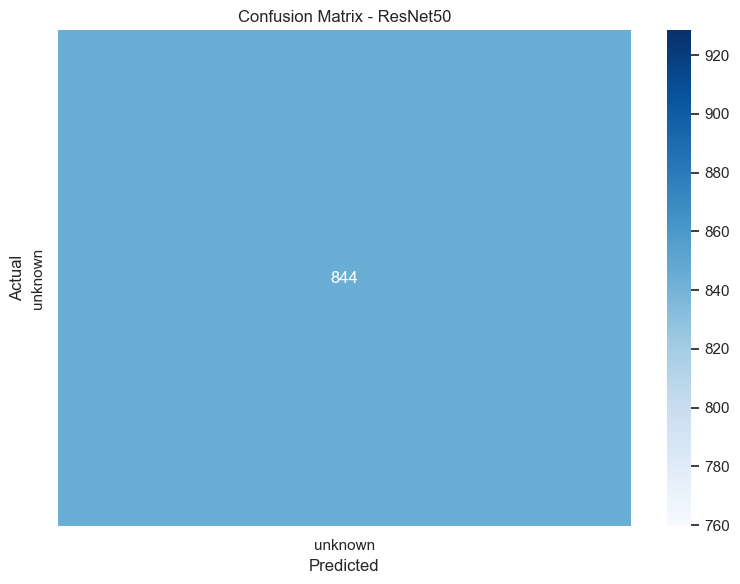

YOLO: found 5626 label files under dataset/labels/**
Skipping YOLO training — existing run found at runs/detect/capstone_yolo_model


In [ ]:

# Section 3: Deep Learning and Advanced Models
# Reproducibility + stdlib

import os
import random
import time
import shutil
import numpy as np

random.seed(42)
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"


# Core libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# TensorFlow / Keras

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Embedding,
    SimpleRNN, LSTM, GRU, Conv1D, MaxPooling1D,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# Plotting
import matplotlib.pyplot as plt
import seaborn as sns


# YOLO (guarded import)

try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
except Exception as e:
    YOLO_AVAILABLE = False
    print("YOLO unavailable, skipping detection later. Reason:", str(e))



# Section 3.0: Load and prepare review data

df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", nrows=50000)
df.dropna(subset=["review_body", "star_rating"], inplace=True)
df = df[df["star_rating"].isin([1, 2, 4, 5])]
df["review_body"] = df["review_body"].str.lower().str.replace(r"[^a-z0-9\s]", "", regex=True)

# TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(df["review_body"]).toarray()

# Labels for Keras (one hot) and for PyTorch (integer)
encoder = OneHotEncoder(sparse_output=False)
y_keras = encoder.fit_transform(df["star_rating"].values.reshape(-1, 1))
label_encoder = LabelEncoder()
y_pytorch = label_encoder.fit_transform(df["star_rating"].values)

# Use 1D labels for stratify
y_labels = df["star_rating"].values

# Split once for Keras and once for PyTorch
X_train, X_test, y_train, y_test = train_test_split(
    X, y_keras, test_size=0.2, random_state=42, stratify=y_labels
)
X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(
    X, y_pytorch, test_size=0.2, random_state=42, stratify=y_pytorch
)



# Section 3.1: Single Layer Perceptron (Keras)

print("\n=== Section 3.1: Single-Layer Perceptron (Keras) ===")
perceptron = Sequential([Dense(4, activation="softmax", input_shape=(X_train.shape[1],))])
perceptron.compile(optimizer=Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])
perceptron.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

y_pred = perceptron.predict(X_test).argmax(axis=1)
y_true = y_test.argmax(axis=1)
print(classification_report(y_true, y_pred, target_names=encoder.categories_[0].astype(str)))



# Section 3.2: Deep Neural Network with regularization (Keras)
# Cell 3c: YOLO caching 
import os
from pathlib import Path

try:
    from ultralytics import YOLO
    have_ultra = True
except Exception as e:
    have_ultra = False
    print("Ultralytics not available:", e)

def _count_txt(root="dataset"):
    c = 0
    for p, _, files in os.walk(root):
        for f in files:
            if f.endswith(".txt"):
                c += 1
    return c

RUNS_DIR = Path("runs/detect/capstone_yolo_model")
if have_ultra:
    num_label_files = _count_txt("dataset")
    print(f"YOLO: found {num_label_files} label files")

    if RUNS_DIR.exists():
        print("Skipping YOLO — run already exists")
    elif num_label_files == 0:
        print("Skipping YOLO — no labels found.")
    else:
        epochs = 2 if SMOKE_TEST else 10
        batch = 8 if SMOKE_TEST else 16
        imgsz = 448 if SMOKE_TEST else 640

        @timed("YOLO training")
        def _yolo_train():
            yolo = YOLO("yolov8n.pt")
            yolo.train(data="yolo_dataset.yaml", epochs=epochs, imgsz=imgsz, batch=batch, name="capstone_yolo_model")
            yolo.val()
            if not SMOKE_TEST:
                yolo.export(format="tflite")
        _yolo_train()
else:
    print("YOLO skipped.")



# Section 3.3: PyTorch Classification DNN

print("\n=== Section 3.3: PyTorch Classification DNN ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ClassificationNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1000, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.model(x)

X_train_tensor = torch.tensor(X_train_pt, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_pt, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pt, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_pt, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

model_pt = ClassificationNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

for epoch in range(5):
    model_pt.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_pt(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

model_pt.eval()
with torch.no_grad():
    logits = model_pt(X_test_tensor.to(device))
    y_pred_classes = torch.argmax(logits, axis=1).cpu().numpy()

print(classification_report(y_test_tensor.numpy(), y_pred_classes, target_names=label_encoder.classes_.astype(str)))



# Section 3.4: Keras vs PyTorch Comparison 
import time

print("\nSection 3.4: Keras vs PyTorch Comparison ")

# Pick whichever Keras model exists
keras_model = locals().get("model_dnn", None) or locals().get("perceptron", None)
if keras_model is None:
    raise NameError("Neither 'model_dnn' nor 'perceptron' is defined. "
                    "Train one in Section 3.1 or 3.2 before running this cell.")

# Keras timing
start_time_keras = time.time()
keras_model.fit(X_train, y_train, validation_split=0.1, epochs=5, batch_size=64, verbose=0)
keras_train_time = time.time() - start_time_keras

y_pred_keras = keras_model.predict(X_test).argmax(axis=1)
y_true_keras = y_test.argmax(axis=1) 
keras_acc = accuracy_score(y_true_keras, y_pred_keras)

# PyTorch timing 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor2 = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor2 = torch.tensor(np.argmax(y_train, axis=1), dtype=torch.long).to(device)
train_dataset2 = TensorDataset(X_train_tensor2, y_train_tensor2)
train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True)

class ClassificationNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.model(x)

model_pt2 = ClassificationNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model_pt2.parameters(), lr=0.001)

start_time_pt = time.time()
for epoch in range(5):
    model_pt2.train()
    for xb, yb in train_loader2:
        pred = model_pt2(xb)
        loss = loss_fn(pred, yb)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
pt_train_time = time.time() - start_time_pt

model_pt2.eval()
with torch.no_grad():
    y_pred_pt = model_pt2(torch.tensor(X_test, dtype=torch.float32).to(device)).argmax(dim=1).cpu().numpy()
pt_acc = accuracy_score(y_true_keras, y_pred_pt)

print(f"Keras Accuracy:   {keras_acc:.4f} | Training Time: {keras_train_time:.2f} seconds")
print(f"PyTorch Accuracy: {pt_acc:.4f} | Training Time: {pt_train_time:.2f} seconds")




# Section 3.5: Sequential text models (RNN, LSTM, GRU, CRNN)

print("\n=== Section 3.5: Sequential Text Models (RNN, LSTM, GRU, CRNN) ===")

df_seq = df.copy()
df_seq["sentiment"] = df_seq["star_rating"].apply(lambda x: 1 if x >= 4 else 0)

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df_seq["review_body"])
seqs = tokenizer.texts_to_sequences(df_seq["review_body"])
padded = pad_sequences(seqs, maxlen=200, padding="post", truncating="post")

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    padded, df_seq["sentiment"].values, test_size=0.2, random_state=42, stratify=df_seq["sentiment"]
)

def train_eval_keras(model, name):
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(X_train_s, y_train_s, validation_split=0.1, epochs=5, batch_size=64, verbose=1)
    y_hat = (model.predict(X_test_s) > 0.5).astype("int32")
    print(f"\nClassification Report ({name}):")
    print(classification_report(y_test_s, y_hat))

# Simple RNN
model_rnn = Sequential([Embedding(10000, 64, input_length=200), SimpleRNN(64), Dense(1, activation="sigmoid")])
train_eval_keras(model_rnn, "RNN Sentiment Classifier")

# LSTM
model_lstm = Sequential([Embedding(10000, 64, input_length=200), LSTM(64), Dense(1, activation="sigmoid")])
train_eval_keras(model_lstm, "LSTM Sentiment Classifier")

# GRU
model_gru = Sequential([Embedding(10000, 64, input_length=200), GRU(64), Dense(1, activation="sigmoid")])
train_eval_keras(model_gru, "GRU Sentiment Classifier")

# CRNN (Conv1D + LSTM)
model_crnn = Sequential([
    Embedding(10000, 64, input_length=200),
    Conv1D(64, 5, activation="relu"),
    MaxPooling1D(2),
    LSTM(64),
    Dense(1, activation="sigmoid")
])
train_eval_keras(model_crnn, "CRNN Sentiment Classifier")



# Section 3.7: Fix images layout + ResNet50 fine-tuning

print("\nSection 3.7: ResNet50 Fine Tuning (folder based)")

#Normalize folder structure 
root = "dataset/images"            
splits = ["train", "val", "test"]
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Move nested splits 
for split in splits:
    sdir = os.path.join(root, split)
    if not os.path.isdir(sdir):
        continue
    for other in splits:
        if other == split:
            continue
        nested = os.path.join(sdir, other)
        if os.path.isdir(nested):
            target = os.path.join(root, other)
            os.makedirs(target, exist_ok=True)
            for name in os.listdir(nested):
                shutil.move(os.path.join(nested, name), os.path.join(target, name))
            try:
                os.rmdir(nested)
            except OSError:
                pass
            print(f"Moved nested '{nested}' into '{target}'")

for split in splits:
    sdir = os.path.join(root, split)
    if not os.path.isdir(sdir):
        print(f"Warning: missing folder: {sdir}")
        continue
    loose = [f for f in os.listdir(sdir)
             if os.path.isfile(os.path.join(sdir, f))
             and f.lower().endswith(valid_ext)]
    if loose:
        unk = os.path.join(sdir, "unknown")
        os.makedirs(unk, exist_ok=True)
        for f in loose:
            shutil.move(os.path.join(sdir, f), os.path.join(unk, f))
        print(f"Moved {len(loose)} images into {unk}")

    classes = [d for d in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, d))]
    if not classes:
        print(f"Warning: {sdir} has no class subfolders. "
              "Expected structure: dataset/images/{{train,val,test}}/{{class}}/img.jpg")

# Generators
image_size = (128, 128)
batch_size = 32

train_aug = ImageDataGenerator(rescale=1./255, rotation_range=25, zoom_range=0.2, horizontal_flip=True)
val_aug   = ImageDataGenerator(rescale=1./255)
test_aug  = ImageDataGenerator(rescale=1./255)

train_gen = train_aug.flow_from_directory(
    os.path.join(root, "train"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical"
)
val_gen = val_aug.flow_from_directory(
    os.path.join(root, "val"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)
test_gen = test_aug.flow_from_directory(
    os.path.join(root, "test"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print(f"train: {train_gen.samples} images | classes: {train_gen.class_indices}")
print(f"val:   {val_gen.samples} images | classes: {val_gen.class_indices}")
print(f"test:  {test_gen.samples} images | classes: {test_gen.class_indices}")

# Hard stop if still empty
if train_gen.samples == 0 or val_gen.samples == 0:
    raise ValueError(
        "No images found for training/validation.\n"
        "Ensure files are under dataset/images/{train,val}/{class_name}/image.jpg"
    )

#3) Build & fine-tune ResNet50 
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
# Unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

cnn_model = Model(inputs=base_model.input, outputs=predictions)
cnn_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

fine_tune_cb = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[fine_tune_cb],
    verbose=1
)

#4) Evaluate 
test_gen.reset()
y_true_img = test_gen.classes
class_labels = list(test_gen.class_indices.keys())
y_pred_img = cnn_model.predict(test_gen)
y_pred_classes_img = np.argmax(y_pred_img, axis=1)

print("\nClassification Report (ResNet50 fine-tuned):")
print(classification_report(y_true_img, y_pred_classes_img, target_names=class_labels))

cm = confusion_matrix(y_true_img, y_pred_classes_img)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



# Section 3.8: YOLOv8 object detection

# YOLO: train only if needed; shorten for smoke test 
import os
from pathlib import Path

try:
    from ultralytics import YOLO
    have_ultra = True
except Exception as e:
    have_ultra = False
    print("Ultralytics not available, skipping YOLO:", e)

def count_txt(root="dataset"):
    c = 0
    for p, _, files in os.walk(root):
        for f in files:
            if f.endswith(".txt"):
                c += 1
    return c

RUNS_DIR = Path("runs/detect/capstone_yolo_model")
if have_ultra:
    num_label_files = count_txt("dataset")
    print(f"YOLO: found {num_label_files} label files under dataset/labels/**")

    if RUNS_DIR.exists():
        print("Skipping YOLO training — existing run found at", RUNS_DIR)
    elif num_label_files == 0:
        print("Skipping YOLO — no .txt labels found.")
    else:
        epochs = 2 if SMOKE_TEST else 10
        batch = 8 if SMOKE_TEST else 16
        imgsz = 448 if SMOKE_TEST else 640

        @timed("YOLO training")
        def yolo_train():
            yolo = YOLO("yolov8n.pt") 
            yolo.train(data="yolo_dataset.yaml", epochs=epochs, imgsz=imgsz, batch=batch, name="capstone_yolo_model")
            yolo.val()
            if not SMOKE_TEST:
                yolo.export(format="tflite")
        yolo_train()
else:
    print("YOLO skipped.")


In [ ]:

#section 4
#Imports 
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
from rapidfuzz import process, fuzz
import openai
import gradio as gr
from datasets import Dataset

# Preprocessing Product Titles 
df = pd.read_csv("amazon_reviews_us_Apparel_v1_00.csv", usecols=["product_id", "product_title", "product_category"])
df.dropna(subset=["product_title", "product_category"], inplace=True)

# Limit for testing
df = df.head(1000)

df["clean_title"] = df["product_title"].str.lower().str.replace(r'[^\w\s]', '', regex=True)


# embedding & FAISS Setup
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["clean_title"].tolist(), show_progress_bar=True)
faiss_index = faiss.IndexFlatL2(embeddings.shape[1])
faiss_index.add(np.array(embeddings).astype("float32"))
product_metadata = df[["product_id", "product_title", "product_category"]].reset_index(drop=True)

# Fuzzy Matching Fallback
def fuzzy_match_product(query, choices, top_n=3):
    return process.extract(query, choices, scorer=fuzz.token_sort_ratio, limit=top_n)

#LLM Prompt Creation
def create_prompt(product_title, product_category):
    return f"""
You are a marketing copywriter for an e-commerce store.

Write a high-quality, persuasive product description.

Product Title: {product_title}
Category: {product_category}

Description:"""

# LLM Completion Call
def generate_description(prompt, temperature=0.8, top_p=0.9):
    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        top_p=top_p
    )
    return response.choices[0].message["content"].strip()

# RAG search FAISS for Related Products 
def search_faiss(query, index, df_metadata, top_k=5):
    query_embedding = model.encode([query])
    D, I = index.search(np.array(query_embedding).astype("float32"), top_k)
    return df_metadata.iloc[I[0]].reset_index(drop=True)

# RAG Build Prompt from Retrieved Context
def build_rag_prompt(query, retrieved_df):
    context = "\n".join([f"- {row['product_title']} ({row['product_category']})" for _, row in retrieved_df.iterrows()])
    return f"""You are a product description generator.

Customer Query: "{query}"

Relevant Products:
{context}

Description:"""

#RAG Generation Function
def rag_generate(query, faiss_index, metadata_df):
    retrieved_df = search_faiss(query, faiss_index, metadata_df)
    prompt = build_rag_prompt(query, retrieved_df)
    return generate_description(prompt)

# Fine-Tuning Dataset Prep (Hugging Face)
df_train = pd.DataFrame({
    "instruction": "Generate a product description",
    "input": df["product_title"] + " (" + df["product_category"] + ")",
    "output": ["Sample description here."] * len(df)
})
dataset = Dataset.from_pandas(df_train)
dataset.to_json("product_data.jsonl")

# Gradio Web Interface 
def run_app(title, category, feedback=None):
    prompt = create_prompt(title, category)
    return generate_description(prompt)

interface = gr.Interface(
    fn=run_app,
    inputs=[
        gr.Textbox(label="Product Title"),
        gr.Textbox(label="Product Category", value="Apparel"),
        gr.Textbox(label="Your Feedback (Optional)")
    ],
    outputs="text",
    title="AI Product Description Generator",
    description="Enter a product title and category to generate a persuasive description."
)

# Launch App 
interface.launch()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 138.73ba/s]


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 3.50.2, however version 4.44.1 is available, please upgrade.
--------
